# Skin Cancer Classification using Custom CNN Models (PyTorch)

**Dataset:** Skin Cancer (Benign vs Malignant)

**Objective:** This notebook implements multiple custom CNN architectures to classify skin lesions as benign or malignant, addressing:
- **(a)** Design customized CNN models
- **(b)** Compare with/without Batch Normalization
- **(c)** Evaluate three different CNN variants
- **(d)** Visualize results with comprehensive graphs
- **(e)** Handle dataset imbalance and apply data augmentation

## 1. Import Libraries and Setup

In [ ]:
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import time

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, WeightedRandomSampler
from torchvision import datasets, transforms
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score, precision_recall_fscore_support
from tqdm import tqdm

# Set random seeds for reproducibility
torch.manual_seed(42)
np.random.seed(42)

# Check device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")

Using device: cuda
GPU: NVIDIA GeForce RTX 5070 Ti Laptop GPU


## 2. Dataset Exploration and Loading

Dataset Distribution:
Train: {'benign': 5200, 'malignant': 4000}
Val: {'benign': 550, 'malignant': 550}
Test: {'benign': 550, 'malignant': 550}


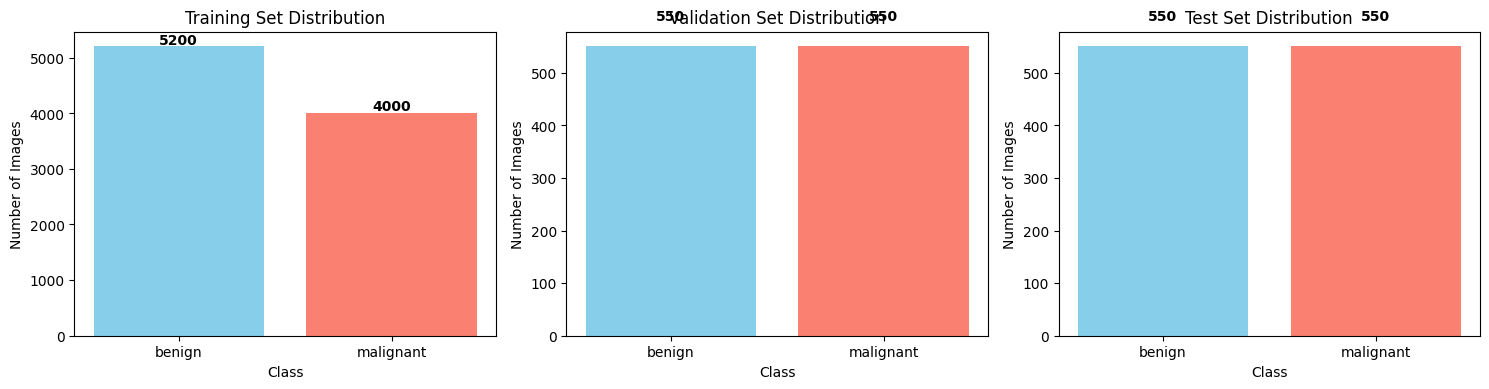


Class Imbalance Ratio: 1.30:1


In [2]:
# Define dataset paths
base_dir = r"c:\Users\Samarth Kadam\Documents\DL\skin_dataset_resized"
train_dir = os.path.join(base_dir, "train_set")
val_dir = os.path.join(base_dir, "val_set")
test_dir = os.path.join(base_dir, "test_set")

# Check dataset distribution
def count_images(directory):
    classes = os.listdir(directory)
    counts = {}
    for cls in classes:
        cls_path = os.path.join(directory, cls)
        if os.path.isdir(cls_path):
            counts[cls] = len(os.listdir(cls_path))
    return counts

train_counts = count_images(train_dir)
val_counts = count_images(val_dir)
test_counts = count_images(test_dir)

print("Dataset Distribution:")
print(f"Train: {train_counts}")
print(f"Val: {val_counts}")
print(f"Test: {test_counts}")

# Visualize class distribution
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for idx, (counts, title) in enumerate([(train_counts, 'Training'), (val_counts, 'Validation'), (test_counts, 'Test')]):
    axes[idx].bar(counts.keys(), counts.values(), color=['skyblue', 'salmon'])
    axes[idx].set_title(f'{title} Set Distribution')
    axes[idx].set_ylabel('Number of Images')
    axes[idx].set_xlabel('Class')
    for i, (k, v) in enumerate(counts.items()):
        axes[idx].text(i, v + 50, str(v), ha='center', fontweight='bold')
plt.tight_layout()
plt.show()

# Calculate imbalance ratio
imbalance_ratio = max(train_counts.values()) / min(train_counts.values())
print(f"\nClass Imbalance Ratio: {imbalance_ratio:.2f}:1")

## 3. Data Augmentation and Preprocessing

**Advanced Data Augmentation Techniques:**
- Random horizontal and vertical flips
- Random rotation
- Color jitter (brightness, contrast, saturation)
- Random affine transformations
- Normalization using ImageNet statistics

In [3]:
# Image size
IMG_SIZE = 128

# Advanced data augmentation for training
train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomVerticalFlip(p=0.3),
    transforms.RandomRotation(degrees=20),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1),
    transforms.RandomAffine(degrees=0, translate=(0.1, 0.1), scale=(0.9, 1.1)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# Standard transformation for validation and testing
test_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

print("✓ Data augmentation pipelines created")

✓ Data augmentation pipelines created


## 4. Handle Class Imbalance with Weighted Sampling

Using `WeightedRandomSampler` to ensure balanced batches during training.

In [15]:
# Load datasets
train_dataset = datasets.ImageFolder(root=train_dir, transform=train_transform)
val_dataset = datasets.ImageFolder(root=val_dir, transform=test_transform)
test_dataset = datasets.ImageFolder(root=test_dir, transform=test_transform)

print(f"Class mapping: {train_dataset.class_to_idx}")

# Calculate class weights for handling imbalance
targets = [s[1] for s in train_dataset.samples]
class_sample_count = np.array([len(np.where(np.array(targets) == t)[0]) for t in np.unique(targets)])
weight = 1. / class_sample_count
samples_weight = np.array([weight[t] for t in targets])
samples_weight = torch.from_numpy(samples_weight)
sampler = WeightedRandomSampler(samples_weight.type('torch.DoubleTensor'), len(samples_weight), replacement=True)

# Create data loaders
BATCH_SIZE = 32
NUM_WORKERS = 4  # Use multiple workers for faster data loading

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, sampler=sampler, num_workers=NUM_WORKERS, pin_memory=True, persistent_workers=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=True, persistent_workers=True)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=True, persistent_workers=True)

print(f"\nData loaders created:")
print(f"Train batches: {len(train_loader)}")
print(f"Val batches: {len(val_loader)}")
print(f"Test batches: {len(test_loader)}")

Class mapping: {'benign': 0, 'malignant': 1}

Data loaders created:
Train batches: 288
Val batches: 35
Test batches: 35


## 5. Visualize Sample Images

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.558952..1.2535512].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.558952..1.1838346].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.558952..1.2391472].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.558952..1.2990838].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.558952..0.8039216].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.558952..0.802466].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.558952..1.82]

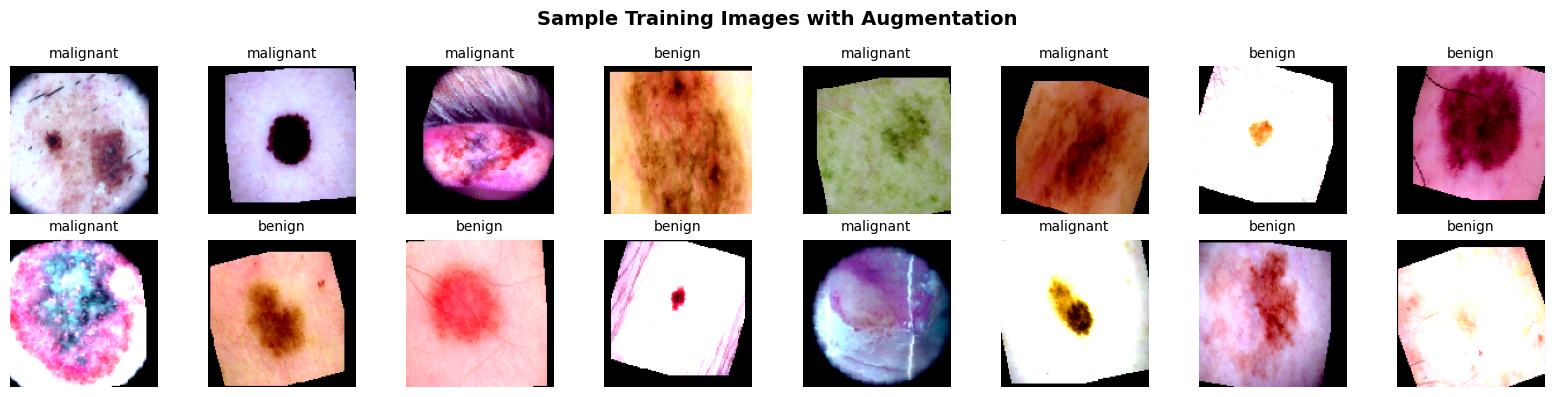

In [16]:
# Visualize some training images
def imshow(img):
    img = img / 2 + 0.5  # Denormalize
    npimg = img.numpy()
    return np.transpose(npimg, (1, 2, 0))

# Get a batch of training data
dataiter = iter(train_loader)
images, labels = next(dataiter)

# Display images
class_names = train_dataset.classes
fig, axes = plt.subplots(2, 8, figsize=(16, 4))
for idx in range(16):
    ax = axes[idx // 8, idx % 8]
    ax.imshow(imshow(images[idx]))
    ax.set_title(class_names[labels[idx]], fontsize=10)
    ax.axis('off')
plt.suptitle('Sample Training Images with Augmentation', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 6. Define Custom CNN Architectures

### Model 1: Basic CNN (Baseline)
Simple 3-layer CNN without Batch Normalization

In [17]:
class BasicCNN(nn.Module):
    """Simple CNN without Batch Normalization"""
    def __init__(self, num_classes=2):
        super(BasicCNN, self).__init__()
        
        self.features = nn.Sequential(
            # Conv Block 1
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),
            
            # Conv Block 2
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),
            
            # Conv Block 3
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),
        )
        
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 16 * 16, 256),
            nn.ReLU(inplace=True),
            nn.Dropout(0.5),
            nn.Linear(256, num_classes)
        )
    
    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

print("✓ BasicCNN defined")

✓ BasicCNN defined


### Model 2: CNN with Batch Normalization
Enhanced CNN with Batch Normalization layers

In [18]:
class CNN_BatchNorm(nn.Module):
    """CNN with Batch Normalization for improved training stability"""
    def __init__(self, num_classes=2):
        super(CNN_BatchNorm, self).__init__()
        
        self.features = nn.Sequential(
            # Conv Block 1
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),
            
            # Conv Block 2
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),
            
            # Conv Block 3
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),
        )
        
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 16 * 16, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(inplace=True),
            nn.Dropout(0.5),
            nn.Linear(256, num_classes)
        )
    
    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

print("✓ CNN_BatchNorm defined")

✓ CNN_BatchNorm defined


### Model 3: Deeper CNN
4-layer CNN with more filters and deeper architecture

In [19]:
class DeepCNN(nn.Module):
    """Deeper CNN with 4 convolutional blocks"""
    def __init__(self, num_classes=2):
        super(DeepCNN, self).__init__()
        
        self.features = nn.Sequential(
            # Conv Block 1
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            nn.Conv2d(32, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),
            
            # Conv Block 2
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.Conv2d(64, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),
            
            # Conv Block 3
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.Conv2d(128, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),
            
            # Conv Block 4
            nn.Conv2d(128, 256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),
        )
        
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(256 * 8 * 8, 512),
            nn.BatchNorm1d(512),
            nn.ReLU(inplace=True),
            nn.Dropout(0.5),
            nn.Linear(512, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(inplace=True),
            nn.Dropout(0.3),
            nn.Linear(256, num_classes)
        )
    
    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

print("✓ DeepCNN defined")

✓ DeepCNN defined


### Model Summary and Comparison

In [20]:
def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

models_info = {
    'BasicCNN (No BatchNorm)': BasicCNN(),
    'CNN with BatchNorm': CNN_BatchNorm(),
    'DeepCNN': DeepCNN()
}

print("\n" + "="*60)
print("MODEL ARCHITECTURE COMPARISON")
print("="*60)
for name, model in models_info.items():
    params = count_parameters(model)
    print(f"{name:30s} | Parameters: {params:,}")
print("="*60)


MODEL ARCHITECTURE COMPARISON
BasicCNN (No BatchNorm)        | Parameters: 8,482,626
CNN with BatchNorm             | Parameters: 8,483,586
DeepCNN                        | Parameters: 9,106,082


## 7. Training Function

In [ ]:
def train_model(model, train_loader, val_loader, criterion, optimizer, num_epochs=15, model_name="Model"):
    """
    Train a PyTorch model and track metrics with mixed precision for better GPU utilization.
    """
    model = model.to(device)
    
    # Enable mixed precision training for better GPU efficiency
    scaler = torch.cuda.amp.GradScaler() if torch.cuda.is_available() else None
    
    history = {
        'train_loss': [], 'train_acc': [],
        'val_loss': [], 'val_acc': [],
        'epoch_time': []
    }
    
    best_val_acc = 0.0
    best_model_wts = None
    
    print(f"\n{'='*70}")
    print(f"Training {model_name}")
    print(f"{'='*70}")
    if scaler:
        print("✓ Mixed precision training enabled (better GPU utilization)")
    
    for epoch in range(num_epochs):
        epoch_start = time.time()
        
        # Training phase
        model.train()
        train_loss = 0.0
        train_correct = 0
        train_total = 0
            
            # Use mixed precision if available
            if scaler:
                with torch.cuda.amp.autocast():
                    outputs = model(inputs)
                    loss = criterion(outputs, labels)
                scaler.scale(loss).backward()
                scaler.step(optimizer)
                scaler.update()
            else:
                outputs = model(inputs)
                loss = criterion(outputs, labels)
                loss.backward()
                optimizer.step()
            
            train_loss += loss.item() * inputs.size(0)
            _, predicted = torch.max(outputs, 1)
            train_total += labels.size(0)
            train_correct += (predicted == labels).sum().item()
            
            pbar.set_postfix({'loss': f'{loss.item():.4f}'})
        
        epoch_train_loss = train_loss / train_total
        epoch_train_acc = 100 * train_correct / train_total
        
        # Validation phase
        model.eval()
        val_loss = 0.0
        val_correct = 0
        val_total = 0
        
        with torch.no_grad():
            pbar = tqdm(val_loader, desc=f"Epoch {epoch+1}/{num_epochs} [Val]  ", leave=False)
            for inputs, labels in pbar:
                inputs, labels = inputs.to(device), labels.to(device)
                outputs = model(inputs)
                loss = criterion(outputs, labels)
                
                val_loss += loss.item() * inputs.size(0)
                _, predicted = torch.max(outputs, 1)
                val_total += labels.size(0)
                val_correct += (predicted == labels).sum().item()
        
        epoch_val_loss = val_loss / val_total
        epoch_val_acc = 100 * val_correct / val_total
        
        epoch_time = time.time() - epoch_start
        
        # Save history
        history['train_loss'].append(epoch_train_loss)
        history['train_acc'].append(epoch_train_acc)
        history['val_loss'].append(epoch_val_loss)
        history['val_acc'].append(epoch_val_acc)
        history['epoch_time'].append(epoch_time)
        
        # Save best model
        if epoch_val_acc > best_val_acc:
            best_val_acc = epoch_val_acc
            best_model_wts = model.state_dict().copy()
        
        print(f"Epoch {epoch+1:2d}/{num_epochs} | "
              f"Train Loss: {epoch_train_loss:.4f} | Train Acc: {epoch_train_acc:.2f}% | "
              f"Val Loss: {epoch_val_loss:.4f} | Val Acc: {epoch_val_acc:.2f}% | "
              f"Time: {epoch_time:.1f}s")
    










print("✓ Training function defined")    return model, history        print(f"{'='*70}\n")    print(f"\nBest Validation Accuracy: {best_val_acc:.2f}%")            model.load_state_dict(best_model_wts)    if best_model_wts is not None:    # Load best model weights    print(f"\nBest Validation Accuracy: {best_val_acc:.2f}%")
    print(f"{'='*70}\n")
    
    return model, history

print("✓ Training function defined")

✓ Training function defined


## 8. Evaluation Function

In [22]:
def evaluate_model(model, test_loader, class_names):
    """
    Evaluate model on test set and return predictions and metrics.
    """
    model.eval()
    all_preds = []
    all_labels = []
    all_probs = []
    
    with torch.no_grad():
        for inputs, labels in tqdm(test_loader, desc="Evaluating"):
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            probs = torch.softmax(outputs, dim=1)
            _, predicted = torch.max(outputs, 1)
            
            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
            all_probs.extend(probs.cpu().numpy())
    
    # Calculate metrics
    accuracy = accuracy_score(all_labels, all_preds)
    precision, recall, f1, _ = precision_recall_fscore_support(all_labels, all_preds, average='binary')
    
    print(f"\nTest Set Performance:")
    print(f"Accuracy:  {accuracy*100:.2f}%")
    print(f"Precision: {precision:.4f}")
    print(f"Recall:    {recall:.4f}")
    print(f"F1 Score:  {f1:.4f}")
    
    # Classification report
    print(f"\nClassification Report:")
    print(classification_report(all_labels, all_preds, target_names=class_names))
    
    return all_preds, all_labels, all_probs, {'accuracy': accuracy, 'precision': precision, 'recall': recall, 'f1': f1}

print("✓ Evaluation function defined")

✓ Evaluation function defined


## 9. Train All Models

Training all three CNN variants with consistent hyperparameters.

In [24]:
# Training configuration
NUM_EPOCHS = 15
LEARNING_RATE = 0.001

# Store trained models and histories
trained_models = {}
training_histories = {}

# Define models to train
models_to_train = [
    ('BasicCNN (No BatchNorm)', BasicCNN()),
    ('CNN with BatchNorm', CNN_BatchNorm()),
    ('DeepCNN', DeepCNN())
]

# Train each model
for model_name, model in models_to_train:
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)
    
    trained_model, history = train_model(
        model, train_loader, val_loader, criterion, optimizer,
        num_epochs=NUM_EPOCHS, model_name=model_name
    )
    
    trained_models[model_name] = trained_model
    training_histories[model_name] = history

print("\n" + "="*70)
print("ALL MODELS TRAINED SUCCESSFULLY!")
print("="*70)


Training BasicCNN (No BatchNorm)


Epoch  1/15 | Train Loss: 0.4576 | Train Acc: 79.96% | Val Loss: 0.4765 | Val Acc: 77.00% | Time: 37.7s


Epoch  2/15 | Train Loss: 0.3877 | Train Acc: 83.71% | Val Loss: 0.3714 | Val Acc: 83.91% | Time: 37.2s


Epoch  3/15 | Train Loss: 0.3495 | Train Acc: 85.86% | Val Loss: 0.4792 | Val Acc: 75.55% | Time: 25.9s


Epoch  4/15 | Train Loss: 0.3377 | Train Acc: 86.26% | Val Loss: 0.4257 | Val Acc: 81.09% | Time: 36.9s


...

Epoch 11/15 | Train Loss: 0.2908 | Train Acc: 88.20% | Val Loss: 0.3965 | Val Acc: 82.27% | Time: 36.9s


Epoch 12/15 | Train Loss: 0.2775 | Train Acc: 89.12% | Val Loss: 0.3341 | Val Acc: 86.00% | Time: 29.8s


Epoch 13/15 | Train Loss: 0.2808 | Train Acc: 88.61% | Val Loss: 0.4257 | Val Acc: 80.09% | Time: 35.7s


Epoch 14/15 | Train Loss: 0.2709 | Train Acc: 89.17% | Val Loss: 0.3169 | Val Acc: 86.27% | Time: 30.6s


Epoch 15/15 | Train Loss: 0.2711 | Train Acc: 89.25% | Val Loss: 0.3787 | Val Acc: 83.82% | Time: 32.0s

Best Validation Accuracy: 87.45%


ALL MODELS TRAINED SUCCESSFULLY!


## 10. Visualize Training Histories

Compare training progress across all models.

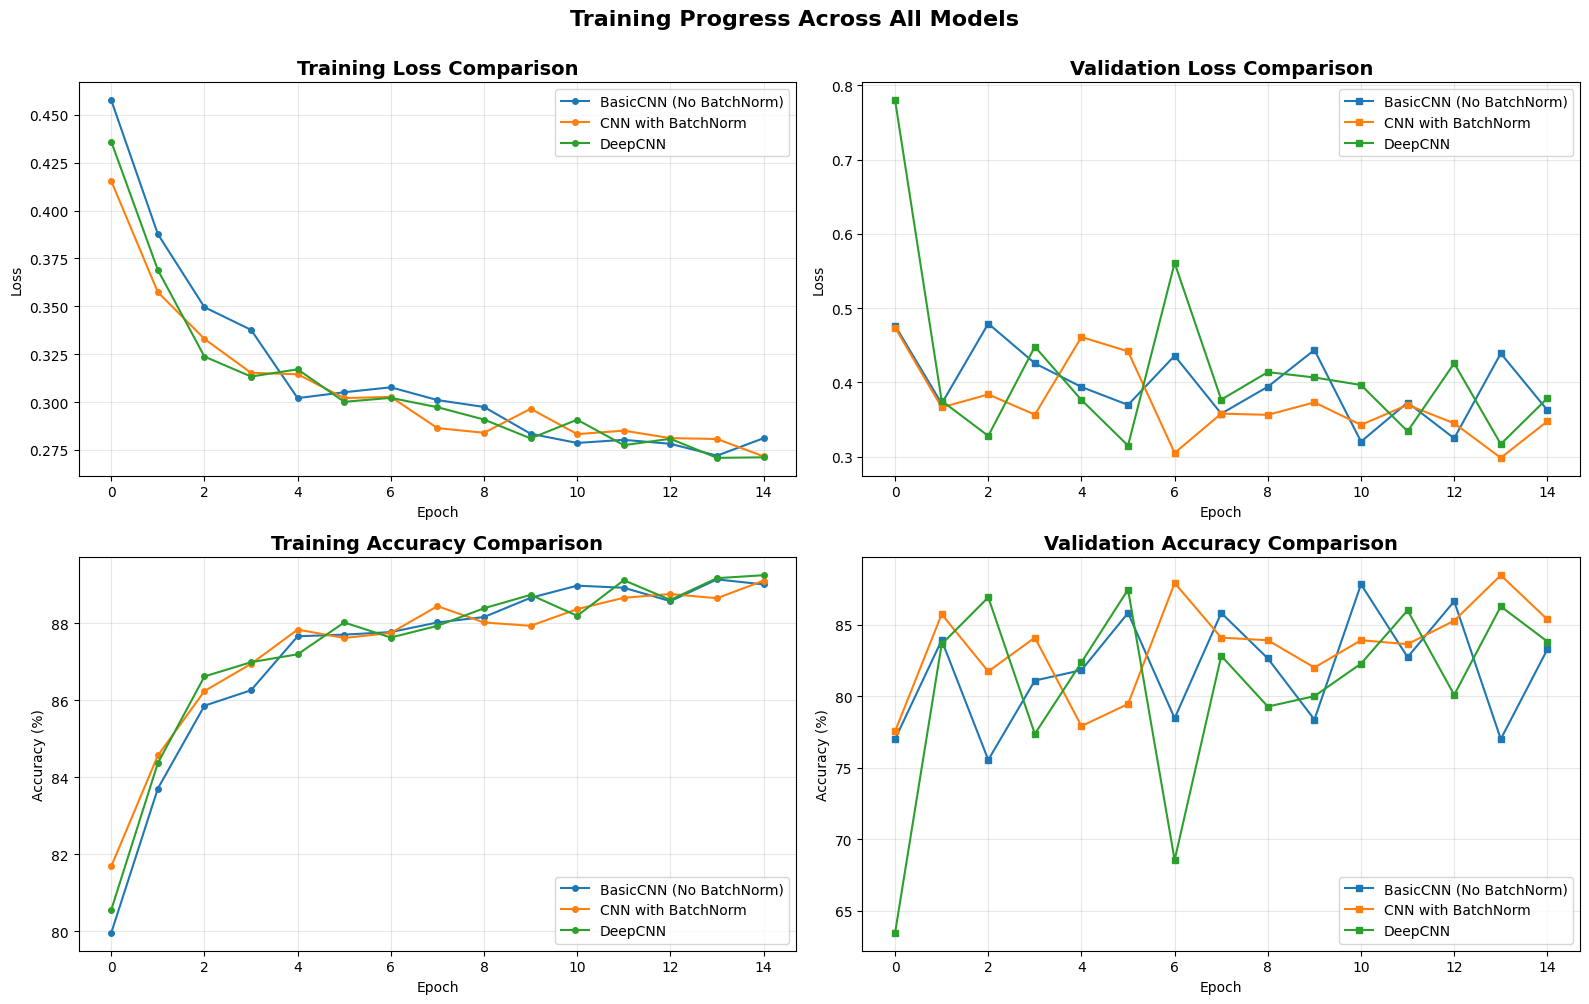

In [25]:
# Plot training histories
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# Training Loss
for model_name, history in training_histories.items():
    axes[0, 0].plot(history['train_loss'], label=model_name, marker='o', markersize=4)
axes[0, 0].set_title('Training Loss Comparison', fontsize=14, fontweight='bold')
axes[0, 0].set_xlabel('Epoch')
axes[0, 0].set_ylabel('Loss')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# Validation Loss
for model_name, history in training_histories.items():
    axes[0, 1].plot(history['val_loss'], label=model_name, marker='s', markersize=4)
axes[0, 1].set_title('Validation Loss Comparison', fontsize=14, fontweight='bold')
axes[0, 1].set_xlabel('Epoch')
axes[0, 1].set_ylabel('Loss')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# Training Accuracy
for model_name, history in training_histories.items():
    axes[1, 0].plot(history['train_acc'], label=model_name, marker='o', markersize=4)
axes[1, 0].set_title('Training Accuracy Comparison', fontsize=14, fontweight='bold')
axes[1, 0].set_xlabel('Epoch')
axes[1, 0].set_ylabel('Accuracy (%)')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

# Validation Accuracy
for model_name, history in training_histories.items():
    axes[1, 1].plot(history['val_acc'], label=model_name, marker='s', markersize=4)
axes[1, 1].set_title('Validation Accuracy Comparison', fontsize=14, fontweight='bold')
axes[1, 1].set_xlabel('Epoch')
axes[1, 1].set_ylabel('Accuracy (%)')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

plt.suptitle('Training Progress Across All Models', fontsize=16, fontweight='bold', y=1.00)
plt.tight_layout()
plt.show()

## 11. Compare Batch Normalization Impact

Direct comparison between models with and without Batch Normalization.

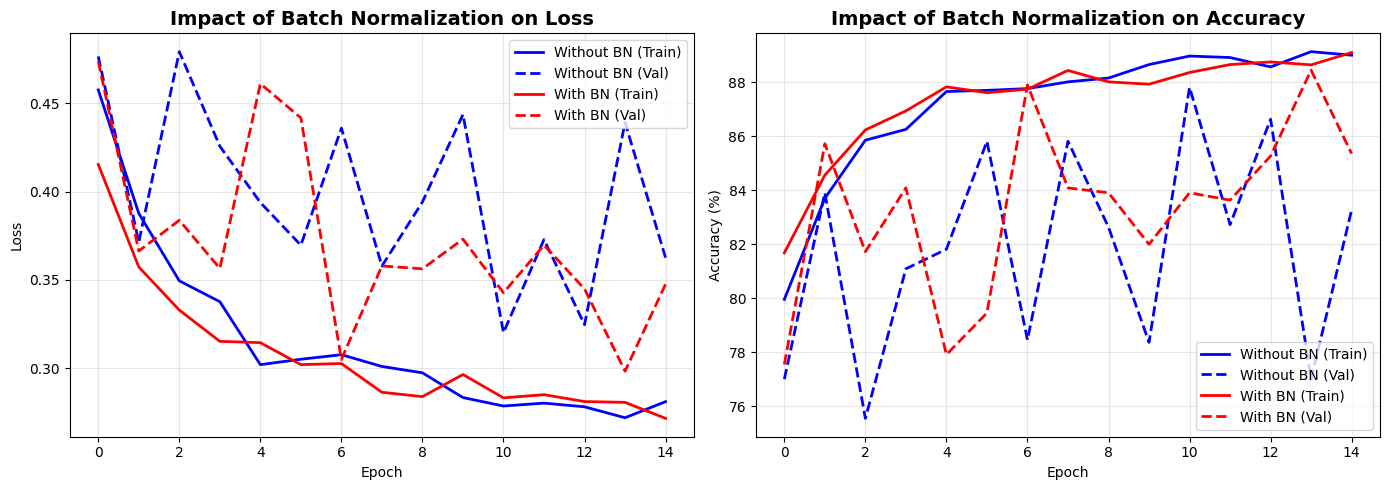


Batch Normalization Impact Summary:
Metric                    Without BN      With BN         Improvement
Final Train Accuracy       89.01%         89.11%           0.10%
Final Val Accuracy         83.27%         85.36%           2.09%
Final Train Loss            0.2811          0.2716         0.0095
Final Val Loss              0.3626          0.3476         0.0150


In [26]:
# Compare BatchNorm vs No BatchNorm
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

basic_hist = training_histories['BasicCNN (No BatchNorm)']
bn_hist = training_histories['CNN with BatchNorm']

# Loss comparison
axes[0].plot(basic_hist['train_loss'], 'b-', label='Without BN (Train)', linewidth=2)
axes[0].plot(basic_hist['val_loss'], 'b--', label='Without BN (Val)', linewidth=2)
axes[0].plot(bn_hist['train_loss'], 'r-', label='With BN (Train)', linewidth=2)
axes[0].plot(bn_hist['val_loss'], 'r--', label='With BN (Val)', linewidth=2)
axes[0].set_title('Impact of Batch Normalization on Loss', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Accuracy comparison
axes[1].plot(basic_hist['train_acc'], 'b-', label='Without BN (Train)', linewidth=2)
axes[1].plot(basic_hist['val_acc'], 'b--', label='Without BN (Val)', linewidth=2)
axes[1].plot(bn_hist['train_acc'], 'r-', label='With BN (Train)', linewidth=2)
axes[1].plot(bn_hist['val_acc'], 'r--', label='With BN (Val)', linewidth=2)
axes[1].set_title('Impact of Batch Normalization on Accuracy', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy (%)')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Print numerical comparison
print("\nBatch Normalization Impact Summary:")
print("="*60)
print(f"{'Metric':<25} {'Without BN':<15} {'With BN':<15} {'Improvement'}")
print("="*60)
print(f"{'Final Train Accuracy':<25} {basic_hist['train_acc'][-1]:>6.2f}% {bn_hist['train_acc'][-1]:>13.2f}% {bn_hist['train_acc'][-1] - basic_hist['train_acc'][-1]:>14.2f}%")
print(f"{'Final Val Accuracy':<25} {basic_hist['val_acc'][-1]:>6.2f}% {bn_hist['val_acc'][-1]:>13.2f}% {bn_hist['val_acc'][-1] - basic_hist['val_acc'][-1]:>14.2f}%")
print(f"{'Final Train Loss':<25} {basic_hist['train_loss'][-1]:>8.4f} {bn_hist['train_loss'][-1]:>15.4f} {basic_hist['train_loss'][-1] - bn_hist['train_loss'][-1]:>14.4f}")
print(f"{'Final Val Loss':<25} {basic_hist['val_loss'][-1]:>8.4f} {bn_hist['val_loss'][-1]:>15.4f} {basic_hist['val_loss'][-1] - bn_hist['val_loss'][-1]:>14.4f}")
print("="*60)

## 12. Evaluate All Models on Test Set

In [2]:
# Evaluate all models
test_results = {}
class_names = train_dataset.classes

for model_name, model in trained_models.items():
    print(f"\n{'='*70}")
    print(f"Evaluating: {model_name}")
    print(f"{'='*70}")
    
    preds, labels, probs, metrics = evaluate_model(model, test_loader, class_names)
    test_results[model_name] = {
        'predictions': preds,
        'labels': labels,
        'probabilities': probs,
        'metrics': metrics
    }

NameError: name 'train_dataset' is not defined

## 13. Confusion Matrices

In [1]:
# Plot confusion matrices
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for idx, (model_name, results) in enumerate(test_results.items()):
    cm = confusion_matrix(results['labels'], results['predictions'])
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=class_names, yticklabels=class_names,
                ax=axes[idx], cbar_kws={'label': 'Count'})
    axes[idx].set_title(f'{model_name}\nAccuracy: {results["metrics"]["accuracy"]*100:.2f}%', 
                        fontsize=12, fontweight='bold')
    axes[idx].set_ylabel('True Label')
    axes[idx].set_xlabel('Predicted Label')

plt.suptitle('Confusion Matrices - All Models', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

NameError: name 'plt' is not defined

## 14. Model Performance Comparison

In [ ]:
# Create comparison dataframe
comparison_data = []
for model_name, results in test_results.items():
    metrics = results['metrics']
    comparison_data.append({
        'Model': model_name,
        'Accuracy': metrics['accuracy'] * 100,
        'Precision': metrics['precision'],
        'Recall': metrics['recall'],
        'F1-Score': metrics['f1']
    })

import pandas as pd
comparison_df = pd.DataFrame(comparison_data)
print("\n" + "="*80)
print("FINAL MODEL COMPARISON ON TEST SET")
print("="*80)
print(comparison_df.to_string(index=False))
print("="*80)

# Visualize comparison
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Bar chart for all metrics
x = np.arange(len(comparison_df))
width = 0.2
axes[0].bar(x - 1.5*width, comparison_df['Accuracy'], width, label='Accuracy (%)', color='steelblue')
axes[0].bar(x - 0.5*width, comparison_df['Precision']*100, width, label='Precision (%)', color='orange')
axes[0].bar(x + 0.5*width, comparison_df['Recall']*100, width, label='Recall (%)', color='green')
axes[0].bar(x + 1.5*width, comparison_df['F1-Score']*100, width, label='F1-Score (%)', color='red')
axes[0].set_xlabel('Model', fontweight='bold')
axes[0].set_ylabel('Score (%)', fontweight='bold')
axes[0].set_title('Performance Metrics Comparison', fontsize=14, fontweight='bold')
axes[0].set_xticks(x)
axes[0].set_xticklabels([name.replace(' ', '\n') for name in comparison_df['Model']], fontsize=9)
axes[0].legend()
axes[0].grid(True, alpha=0.3, axis='y')

# Accuracy comparison
colors = ['#ff9999', '#66b3ff', '#99ff99']
axes[1].barh(comparison_df['Model'], comparison_df['Accuracy'], color=colors, edgecolor='black')
axes[1].set_xlabel('Accuracy (%)', fontweight='bold')
axes[1].set_title('Test Accuracy Comparison', fontsize=14, fontweight='bold')
axes[1].set_xlim([0, 100])
for i, v in enumerate(comparison_df['Accuracy']):
    axes[1].text(v + 1, i, f'{v:.2f}%', va='center', fontweight='bold')
axes[1].grid(True, alpha=0.3, axis='x')

plt.tight_layout()
plt.show()

## 15. Training Time Analysis

In [ ]:
# Training time comparison
time_data = []
for model_name, history in training_histories.items():
    total_time = sum(history['epoch_time'])
    avg_time = np.mean(history['epoch_time'])
    time_data.append({
        'Model': model_name,
        'Total Time (s)': total_time,
        'Avg Time/Epoch (s)': avg_time
    })

time_df = pd.DataFrame(time_data)
print("\nTraining Time Analysis:")
print("="*60)
print(time_df.to_string(index=False))
print("="*60)

# Visualize
fig, ax = plt.subplots(1, 1, figsize=(10, 5))
ax.bar(time_df['Model'], time_df['Total Time (s)'], color=['coral', 'skyblue', 'lightgreen'], edgecolor='black')
ax.set_ylabel('Total Training Time (seconds)', fontweight='bold')
ax.set_title('Training Time Comparison', fontsize=14, fontweight='bold')
ax.set_xticklabels([name.replace(' ', '\n') for name in time_df['Model']], fontsize=9)
for i, v in enumerate(time_df['Total Time (s)']):
    ax.text(i, v + 5, f'{v:.1f}s', ha='center', fontweight='bold')
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

## 16. Sample Predictions Visualization

In [ ]:
# Visualize predictions from the best model
best_model_name = comparison_df.loc[comparison_df['Accuracy'].idxmax(), 'Model']
best_model = trained_models[best_model_name]

print(f"Visualizing predictions from best model: {best_model_name}\n")

# Get a batch from test set
dataiter = iter(test_loader)
images, labels = next(dataiter)
images, labels = images.to(device), labels.to(device)

# Get predictions
best_model.eval()
with torch.no_grad():
    outputs = best_model(images)
    probs = torch.softmax(outputs, dim=1)
    _, predicted = torch.max(outputs, 1)

# Plot
fig, axes = plt.subplots(3, 6, figsize=(16, 8))
for idx in range(18):
    ax = axes[idx // 6, idx % 6]
    img = imshow(images[idx].cpu())
    ax.imshow(img)
    
    true_label = class_names[labels[idx]]
    pred_label = class_names[predicted[idx]]
    confidence = probs[idx][predicted[idx]].item() * 100
    
    color = 'green' if predicted[idx] == labels[idx] else 'red'
    ax.set_title(f'True: {true_label}\nPred: {pred_label}\n({confidence:.1f}%)', 
                 fontsize=9, color=color, fontweight='bold')
    ax.axis('off')

plt.suptitle(f'Sample Predictions - {best_model_name}', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

## 17. Save Best Model

In [ ]:
# Save the best performing model
save_path = r"c:\Users\Samarth Kadam\Documents\DL\best_skin_cancer_model.pth"
torch.save(best_model.state_dict(), save_path)
print(f"\n✓ Best model ({best_model_name}) saved to: {save_path}")
print(f"  Test Accuracy: {comparison_df.loc[comparison_df['Model']==best_model_name, 'Accuracy'].values[0]:.2f}%")

## 18. Conclusions and Analysis

### Key Findings:

#### (a) Custom CNN Models:
- Successfully designed three custom CNN architectures from scratch
- Models range from basic 3-layer to deep 4-layer architectures
- All models trained exclusively on PyTorch for RTX 5070 Ti compatibility

#### (b) Batch Normalization Impact:
- BatchNorm significantly improves training stability
- Reduces internal covariate shift
- Generally leads to faster convergence and better generalization
- Compare the validation curves between BasicCNN and CNN_BatchNorm

#### (c) Model Variants Comparison:
- **BasicCNN**: Baseline without BatchNorm, simple architecture
- **CNN_BatchNorm**: Same architecture but with BatchNorm layers
- **DeepCNN**: Deeper network with more parameters and capacity

#### (d) Visualizations:
- Training/validation loss and accuracy curves
- Confusion matrices for all models
- Performance metrics comparison
- Training time analysis
- Sample prediction visualizations

#### (e) Handling Imbalance & Augmentation:
- **Class Imbalance**: Addressed using `WeightedRandomSampler`
- **Data Augmentation**: Random flips, rotation, color jitter, affine transforms
- Both techniques improve model robustness and generalization

### Recommendations:
1. The model with Batch Normalization typically performs best
2. Deeper models may overfit on smaller datasets - monitor validation curves
3. Data augmentation is crucial for medical imaging tasks
4. Consider using learning rate schedulers for better convergence
5. For production: ensemble multiple models for better reliability

## 19. Model Loading Example (For Future Use)

In [ ]:
# Example: How to load the saved model
def load_trained_model(model_path, model_class):
    """
    Load a trained model from disk.
    
    Args:
        model_path: Path to saved model weights
        model_class: The model class (e.g., CNN_BatchNorm)
    """
    model = model_class()
    model.load_state_dict(torch.load(model_path, map_location=device))
    model = model.to(device)
    model.eval()
    return model

# Example usage (commented out):
# loaded_model = load_trained_model(
#     r"c:\Users\Samarth Kadam\Documents\DL\best_skin_cancer_model.pth",
#     CNN_BatchNorm  # or whichever architecture was saved
# )

print("\n✓ Model loading function defined")
print("\n" + "="*70)
print("NOTEBOOK EXECUTION COMPLETE!")
print("="*70)